# Transformer Model Results (Experiment #2)

Evaluates the trained Hybrid CNN + Factorized Space-Time Transformer U-Net precipitation retrieval model on the SatRain Korea and CONUS test domains. Inputs are temporal ABI (`geo_t`, 7 timesteps x 16 channels), GMI (13 channels), and ancillary variables (6 channels). Only the architecture and the temporal ABI input differ from the baseline UNet — loss, targets, thresholds, optimizer, augmentation, precision, and eval harness are identical.

## Setup

Configure input data path and define the three input streams: GMI (passive microwave), temporal ABI (`GeoT`, 7 timesteps of geostationary infrared), and ancillary surface/environment variables.

In [ ]:
%load_ext autoreload
%autoreload 2
from satrain.input import GMI, Ancillary, GeoT
from satrain.target import TargetConfig
import os

os.environ["SATRAIN_DATA_PATH"] = "/explore/nobackup/projects/pix4dcloud/sanumolu/"

target_config = TargetConfig()
inputs = [
    # PMW Data (13 channels)
    GMI(normalize="minmax", nan=-1.5, include_angles=False),

    # Temporal ABI Data (7 timesteps x 16 channels = 112 features, time-major)
    GeoT(normalize="minmax", nan=-1.5),

    # Ancillary Data (6 variables)
    Ancillary(
        variables=[
            "ten_meter_wind_u",
            "ten_meter_wind_v",
            "two_meter_temperature",
            "two_meter_dew_point",
            "surface_type",
            "elevation"
        ],
        normalize="minmax",
        nan=-1.5
    )
]

geometry = "on_swath"

## Validation Data

Load the validation split via `FastSatRainTemporal` (the same dataset class used for training). It returns `(geo_t, static)` input tuples plus a target dict, matching the transformer's `forward(geo_t, static)` signature exactly — unlike `SatRainSpatial(stack=True)`, which would flatten `geo_t`'s time axis into an undifferentiated channel axis.

In [ ]:
from torch.utils.data import DataLoader
from model_transformer import FastSatRainTemporal

PP_ROOT = "/explore/nobackup/projects/pix4dcloud/sanumolu/satrain_ml/satrain_data/preprocessed/satrain/gmi/{split}/l/on_swath"

batch_size = 32
num_workers = 8

validation_data = FastSatRainTemporal(PP_ROOT.format(split="validation"))
validation_loader = DataLoader(
    validation_data,
    shuffle=False,
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=True,
)

## Model Architecture

A shared-weight per-timestep CNN encoder (`SiameseABIEncoder`) processes each of the 7 ABI timesteps; a factorized space-time Transformer (`SpaceTimeBlock`: temporal attention, then spatial attention, stacked) reasons over the resulting `(B,7,D,h,w)` bottleneck and aggregates over time (`TemporalAggregation`). Skip connections are taken from the reference (overpass) timestep only. The aggregated temporal feature map is fused with a separate static-context encoder (GMI + ancillary) and decoded through a U-Net decoder, producing the same three heads as the baseline: `surface_precip` (MSE), `probability_of_precip`, and `probability_of_heavy_precip` (both BCE). `IPWGTransformer` wraps this in a PyTorch Lightning module with Adam + cosine-annealing LR — identical to the baseline.

## Load Checkpoint

Load the best saved `transformer_v1` checkpoint and set the model to eval mode. Fill in the actual checkpoint filename produced by `run_transformer.slurm` under `transformer_model/checkpoints/`.

In [ ]:
from model_transformer import IPWGTransformer

# Fill in the actual best checkpoint filename from transformer_model/checkpoints/
checkpoint_path = "/explore/nobackup/projects/pix4dcloud/sanumolu/satrain_ml/transformer_model/checkpoints/transformer_v2_fixed-epoch=127-val_loss=0.0964.ckpt"

transformer = IPWGTransformer.load_from_checkpoint(checkpoint_path)
transformer.eval()
print("Model successfully loaded!")

## Validation Sample Plots

Run a single forward pass on the first batch and display retrieved vs. reference precipitation for 32 samples. Missing-data pixels (all inputs below −1.0) are masked out.

In [4]:
# Retrieve first batch from validation loader
import torch
batch = next(iter(validation_loader))
(geo_t, static), y = batch

geo_t = geo_t.to(device="cpu", dtype=torch.float32)
static = static.to(device="cpu", dtype=torch.float32)
transformer = transformer.to(device="cpu", dtype=torch.float32)

# Run inference and extract surface precipitation estimates.
with torch.no_grad():
    pred = transformer(geo_t, static)
    surface_precip = pred["surface_precip"]
surface_precip_ref = y["surface_precip"]

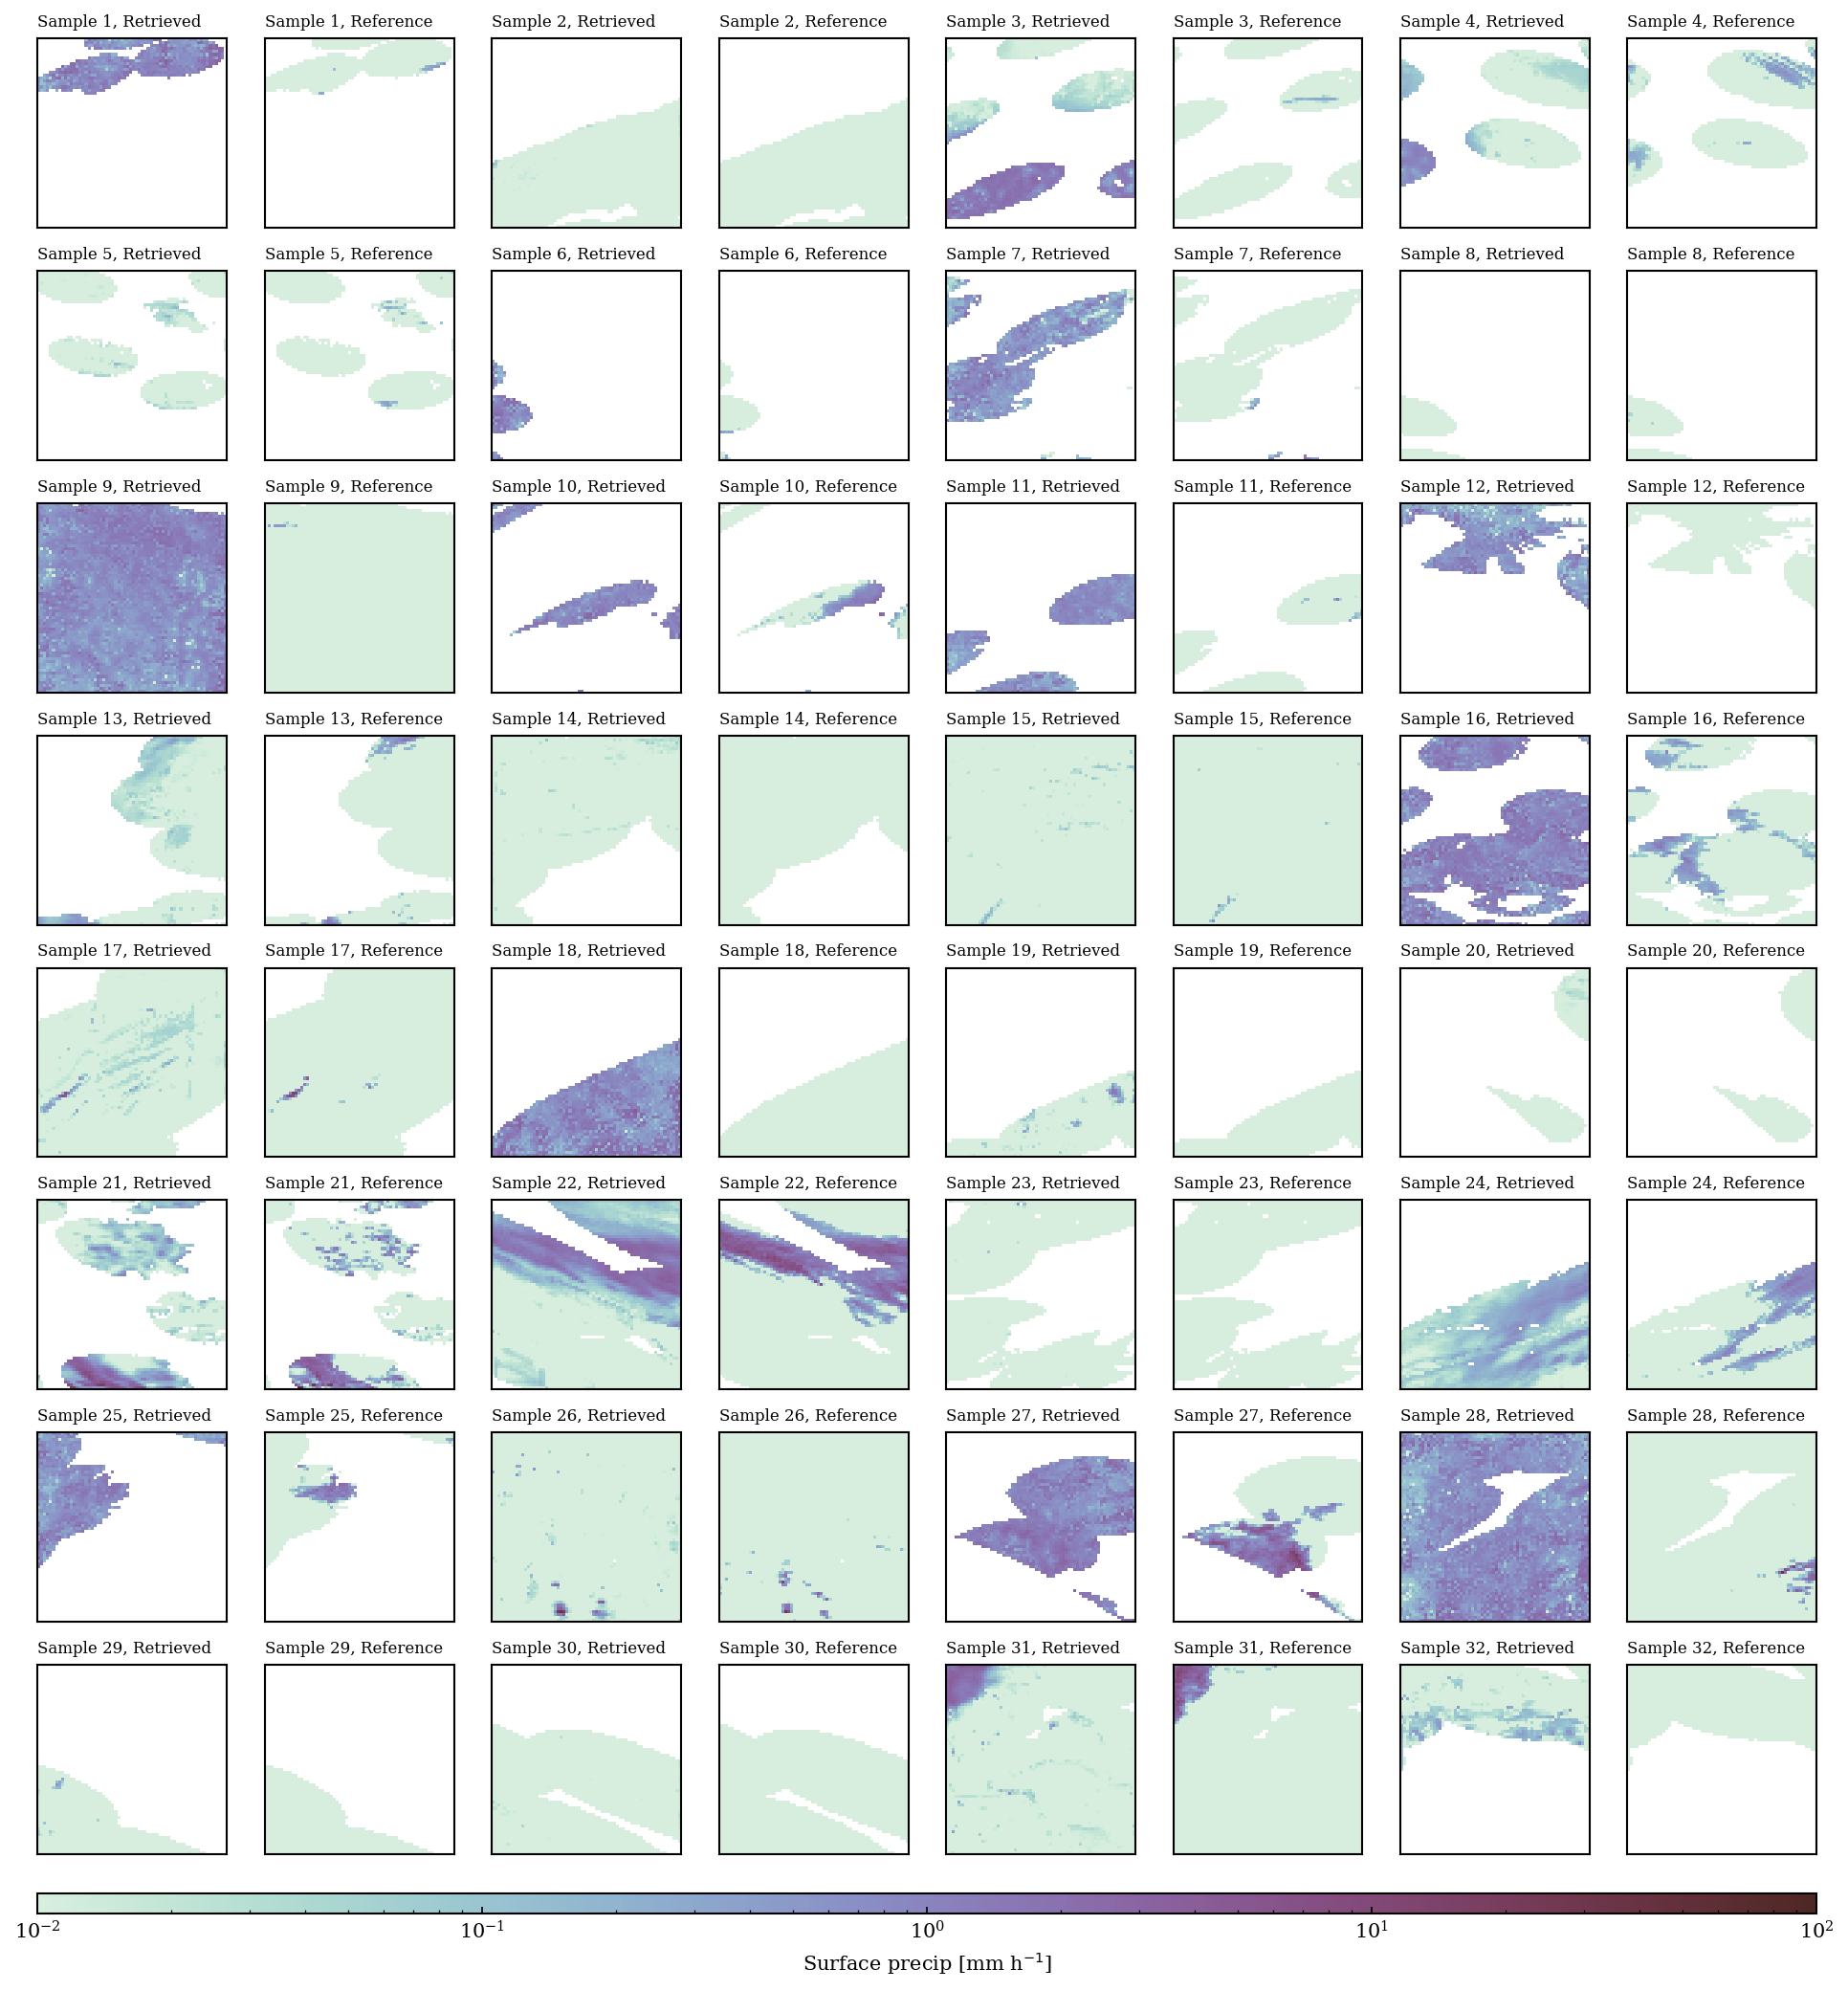

In [12]:
from satrain.plotting import set_style, cmap_precip
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
import numpy as np
import torch

set_style()
fig = plt.figure(figsize=(16, 17))
gs = GridSpec(9, 8, height_ratios = [1.0] * 8 + [0.1])

for row_ind in range(8):
    for col_ind in range(0, 8, 2):

        norm = LogNorm(1e-2, 1e2)
        sample_index = row_ind * 4 + col_ind // 2

        # Mask identifying missing values.
        ref_data = surface_precip_ref[sample_index]
        if torch.is_tensor(ref_data):
            ref_data = ref_data.cpu().numpy()
        mask = np.isnan(ref_data)
        
        ax = fig.add_subplot(gs[row_ind, col_ind])
        precip = np.maximum(surface_precip[sample_index, 0].numpy().copy(), 1e-3)
        precip[mask] = np.nan
        ax.imshow(precip, norm=norm, cmap=cmap_precip)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Sample {sample_index + 1}, Retrieved", fontsize=8)
        
        ax = fig.add_subplot(gs[row_ind, col_ind + 1])
        mappable = ax.imshow(np.maximum(ref_data, 1e-3), norm=norm, cmap=cmap_precip)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Sample {sample_index + 1}, Reference", fontsize=8)

cax = fig.add_subplot(gs[-1, :])
plt.colorbar(mappable, label="Surface precip [mm h$^{-1}$]", cax=cax, orientation="horizontal")

## Evaluation Setup

Build the custom temporal-aware `retrieval_fn` (NOT `PytorchRetrieval(stack=True)`, which would flatten `geo_t`'s time axis into an undifferentiated channel axis and destroy the (T,C) structure the model needs). The evaluator tiles full scenes into 64x64 patches (overlap 16) and accumulates predictions for metric computation.

In [5]:
from retrieval_transformer import make_temporal_retrieval_fn
import torch

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {torch_device}")
transformer = transformer.to(torch_device).eval()

# Custom temporal-aware retrieval callback (raw mm/h surface_precip, logits->sigmoid
# applied inside the callback for the two probability heads). See retrieval_transformer.py.
fn = make_temporal_retrieval_fn(transformer, device=torch_device, dtype=torch.float32)

Running inference on: cuda


In [6]:
from satrain.evaluation import Evaluator
evaluator = Evaluator(
    base_sensor="gmi",
    domain="korea",
    geometry=geometry,
    retrieval_input=inputs,
    download=False
)

WARNING  Environment variable SATRAIN_DATA_PATH

## Case Study

Visual sanity check for a single test scene. The retrieval only produces reliable estimates within the GMI swath; outside the swath, results should be ignored.

In [ ]:
fig = evaluator.plot_retrieval_results(
    501,
    fn,
    input_data_format="spatial",
    tile_size=64,
    batch_size=16,
    swath_boundaries=True,
    include_metrics=True
)

## Run Evaluation

Runs the full test-set evaluation over both eval domains: **Korea** and **CONUS** (Austria is excluded — it has 0 scenes). Results are accumulated per-domain inside `domain_evaluators` and accessed via `get_*_results()` below.

In [ ]:
from satrain.evaluation import Evaluator

MODEL_NAME_BASE = "Transformer (GMI+ABI-temporal)"

# Korea + CONUS only -- Austria has 0 scenes for this base_sensor/geometry.
domain_evaluators = {}
# for domain in ["korea", "conus"]:
for domain in ["korea"]:
    print(f"Starting evaluation for domain={domain}... this may take a few minutes.")
    ev = Evaluator(
        base_sensor="gmi",
        domain=domain,
        geometry=geometry,
        retrieval_input=inputs,
        download=False,
    )
    print(f"{domain}: {len(ev)} scenes")  # scene-count parity check vs. the baseline run
    ev.evaluate(
        retrieval_fn=fn,
        input_data_format="spatial",
        batch_size=32,
        tile_size=64,
        overlap=16,
        output_path="/explore/nobackup/people/sanumolu/satrain_torch/eval_out/transformer/v2_fixed/korea",  # <-- ADD THIS
    )
    domain_evaluators[domain] = ev
    print(f"Evaluation complete for domain={domain}.")

Starting evaluation for domain=korea... this may take a few minutes.


WARNING  Environment variable SATRAIN_DATA_PATH

Output()

korea: 600 scenes


Evaluation complete for domain=korea.
Starting evaluation for domain=conus... this may take a few minutes.


WARNING  Environment variable SATRAIN_DATA_PATH

Output()

conus: 2912 scenes


## Results

Metric tables comparing UNet (GMI) against baseline algorithms across quantification, detection, and probabilistic detection tasks. Followed by a clean printed summary.

### Precipitation estimation

In [ ]:
from IPython.display import display

for domain, ev in domain_evaluators.items():
    name = f"{MODEL_NAME_BASE} - {domain}"
    print(f"\n=== {domain} ===")
    display(ev.get_precip_quantification_results(name=name).T)

### Precipitation detection

In [ ]:
from IPython.display import display

for domain, ev in domain_evaluators.items():
    name = f"{MODEL_NAME_BASE} - {domain}"
    print(f"\n=== {domain} ===")
    display(ev.get_precip_detection_results(name=name).T)

### Probabilistic precipitation detection

In [ ]:
from IPython.display import display

for domain, ev in domain_evaluators.items():
    name = f"{MODEL_NAME_BASE} - {domain}"
    print(f"\n=== {domain} ===")
    display(ev.get_prob_precip_detection_results(name=name).T)

### Heavy precipitation detection

In [ ]:
from IPython.display import display

for domain, ev in domain_evaluators.items():
    name = f"{MODEL_NAME_BASE} - {domain}"
    print(f"\n=== {domain} ===")
    display(ev.get_heavy_precip_detection_results(name=name).T)

### Probabilistic heavy precipitation detection

In [ ]:
from IPython.display import display

for domain, ev in domain_evaluators.items():
    name = f"{MODEL_NAME_BASE} - {domain}"
    print(f"\n=== {domain} ===")
    display(ev.get_prob_heavy_precip_detection_results(name=name).T)

### Summary table of compiled model metrics

In [ ]:
for domain, ev in domain_evaluators.items():
    MODEL_NAME = f"{MODEL_NAME_BASE} - {domain}"

    quant   = ev.get_precip_quantification_results(name=MODEL_NAME).loc[MODEL_NAME]
    detect  = ev.get_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
    prob    = ev.get_prob_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
    hdetect = ev.get_heavy_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
    hprob   = ev.get_prob_heavy_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]

    sections = [
        ("Precipitation Quantification",  quant),
        ("Precipitation Detection",        detect),
        ("Prob. Precipitation Detection",  prob),
        ("Heavy Precip. Detection",        hdetect),
        ("Prob. Heavy Precip. Detection",  hprob),
    ]

    WIDTH = 52
    print(f"{'=' * WIDTH}")
    print(f"  Model: {MODEL_NAME}")
    print(f"{'=' * WIDTH}")
    for title, series in sections:
        print(f"\n  {title}")
        print(f"  {'-' * (WIDTH - 2)}")
        for metric, value in series.items():
            label = metric.strip()
            if isinstance(value, float):
                print(f"  {label:<42}  {value:>8.4f}")
            else:
                print(f"  {label:<42}  {value!r:>8}")
    print(f"\n{'=' * WIDTH}\n")